## 1. Introduction
### Wisconsin Breast Cancer Classification Project 🧬

- Breast cancer is one of the most common types of cancer worldwide, and early detection plays an important role in improving treatment outcomes. Machine learning methods can help identify patterns in medical data and support the classification of tumors.

- In this project, the Breast Cancer Wisconsin dataset is analyzed to classify tumors as malignant or benign. The dataset contains 30 numerical features describing characteristics of cell nuclei, such as radius, texture, perimeter, area, smoothness, and concavity.

- To better understand the structure of the data, exploratory data analysis and dimensionality reduction using Principal Component Analysis (PCA) are performed.
- Several classification models, including Logistic Regression, SVM, KNN, and Random Forest, are then trained and evaluated using metrics such as precision, recall, F1-score, and ROC-AUC.

- In addition to evaluating predictive performance, SHAP analysis is used to interpret the models and identify which features contribute most to tumor classification.

### Research Questions

This project aims to answer the following questions:

- Can machine learning models accurately classify tumors as malignant or benign using the Breast Cancer Wisconsin dataset?

- Which features of the cell nuclei are most important for distinguishing between malignant and benign tumors?

- Which classification model performs best for this task?

**Note**
All analysis, visualizations, and code implementations in this project were developed independently as part of a self‑directed learning project in computational biology.


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc
)

import shap

sns.set_theme(style="whitegrid", palette="muted") 
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Loading the Dataset

This loads the built-in breast cancer dataset from sklearn:

In [3]:
from sklearn.datasets import load_breast_cancer

Load dataset and create a DataFrame for analysis:

In [4]:
# Load the Wisconsin Breast Cancer dataset
cancer = load_breast_cancer()

# Create feature matrix and target series
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)   # 30 numeric features
y = pd.Series(cancer.target, name="target")                   # 0 =malignant, 1 = benign

# Combine into a single DataFrame
df = X.copy()
df["target"] = y

---


## 4. Dataset Overview

In [5]:
# dataset description
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

- The dataset contains 569 samples with 30 numerical features describing
- characteristics of cell nuclei (e.g., radius, texture, area).
- The goal is to classify tumors as malignant or benign.

In [6]:
# feature names
print(cancer['feature_names'])

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


---


## 5. Exploratory Data Analysis

Data Inspection & Descriptive Statistics:

In [7]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
print(X.shape)  

(569, 30)


The dataset has 569 samples and 30 features.



In [9]:
# Mapping target labels for better readability
target_map = {0: 'Malignant', 1: 'Benign'}
y_named = y.map(target_map)
print("Target variable distribution:")
print(y_named.value_counts())

Target variable distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


There are more benign samples (357) than malignant ones (212).

---

In [10]:
print("\nDataset information:")
X.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

- This shows the structure of the feature matrix (number of samples, number of features, and data types) for the breast cancer dataset.
- It helps confirm that all columns are numeric and there are no missing values before modeling.

In [11]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


- This summary shows basic statistics for each feature in the breast cancer dataset, including mean, standard deviation, and value ranges. 
- Most features (such as mean radius, mean perimeter, and mean area) have wide ranges, indicating significant variation in tumor size. 
- We will normalize these features before model training.


---


## 6. Data Cleaning

In [12]:
# Check for missing values
print(X.isnull().sum())

# Check for duplicates
print(f"Duplicate rows: {X.duplicated().sum()}")

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
Duplicate rows: 0


- There are no missing values in any column, and the dataset has zero duplicated rows.
- The data is already clean and we don't need to fix anything here.

---




## 7. Feature Analysis and Visualizations

### 7.1 Correlation Matrix

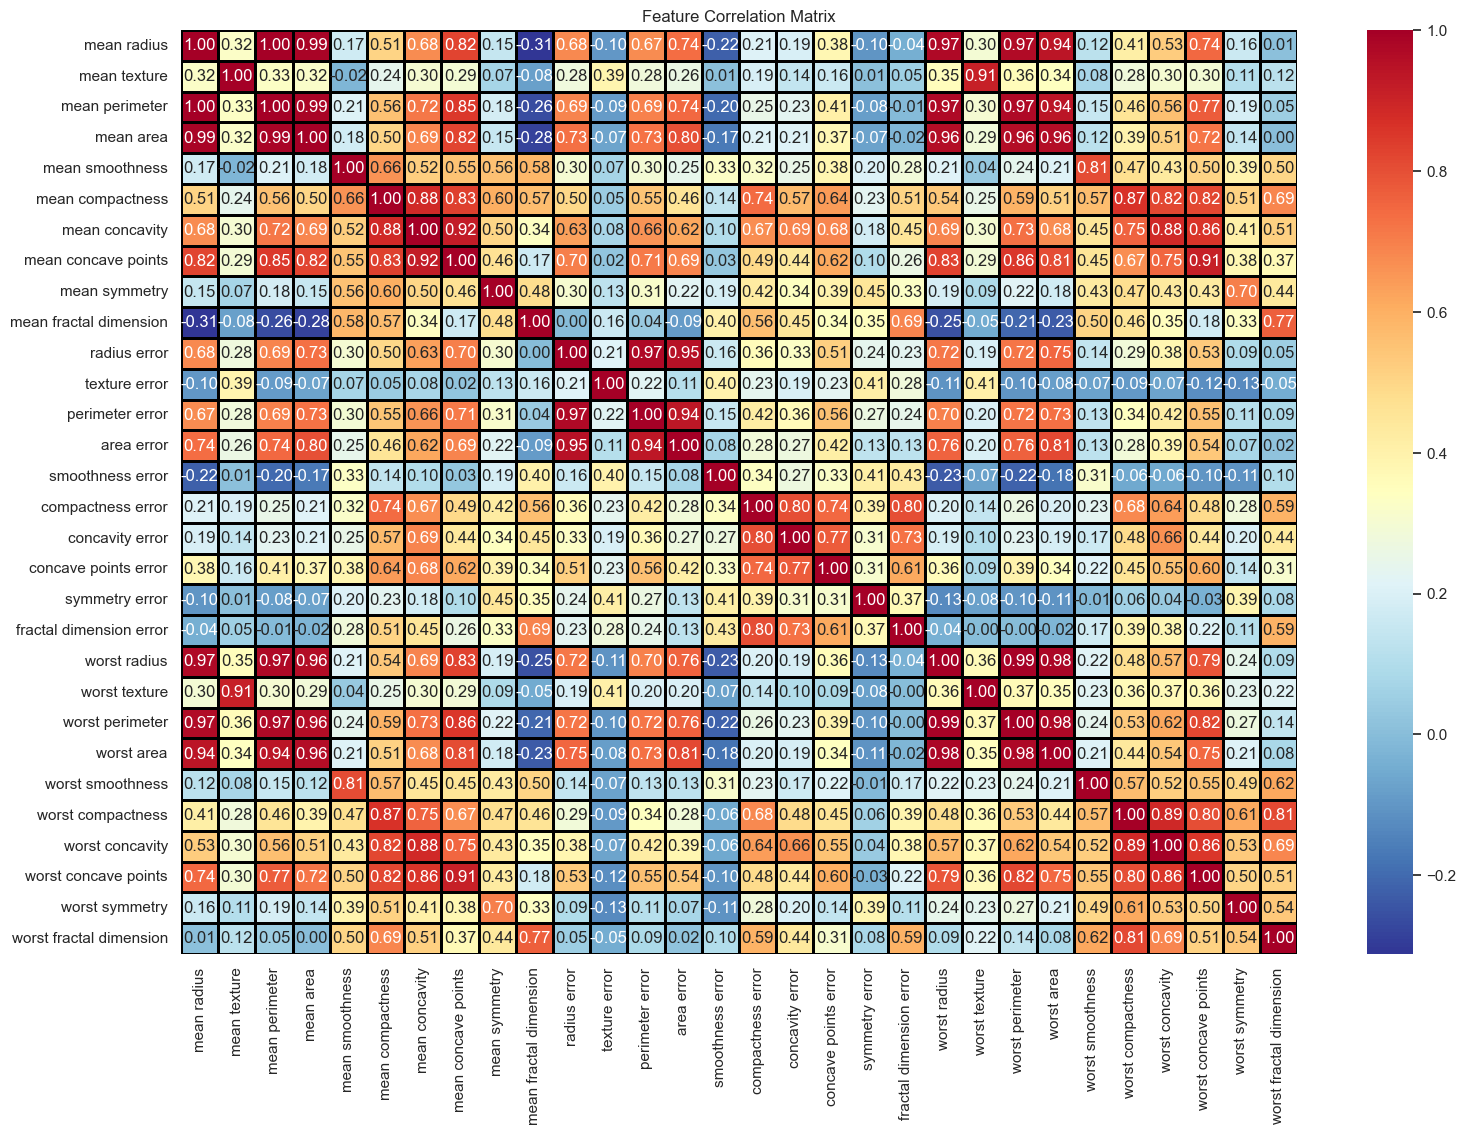

In [13]:
plt.figure(figsize=(18,12))  #width=18 inch, height=12 inch)
sns.heatmap(
    X.corr(),                # compute correlation between all feature pairs
    cmap='RdYlBu_r',         # color map: red for positive, blue for negative (reversed so red = high)
    annot=True,              # write the correlation number inside each cell
    linewidths=0.8,          # thin borders between cells
    linecolor='black',       # color of those borders
    fmt='.2f'                # format numbers to 2 decimal places
    ) 

plt.title("Feature Correlation Matrix")
plt.show()

### Interpretation of Correlation Heatmap

- I plotted a correlation heatmap to check how the features relate to each other. 
- The color scale shows strong positive correlations in red and negative ones in blue. 
- As expected, radius_mean, perimeter_mean, and area_mean are almost perfectly correlated because they all describe tumor size. 
- Knowing this helps avoid using too many redundant features in simple models. 

---

### 7.2 KDE Plots (Distributions for Malignant vs Benign)

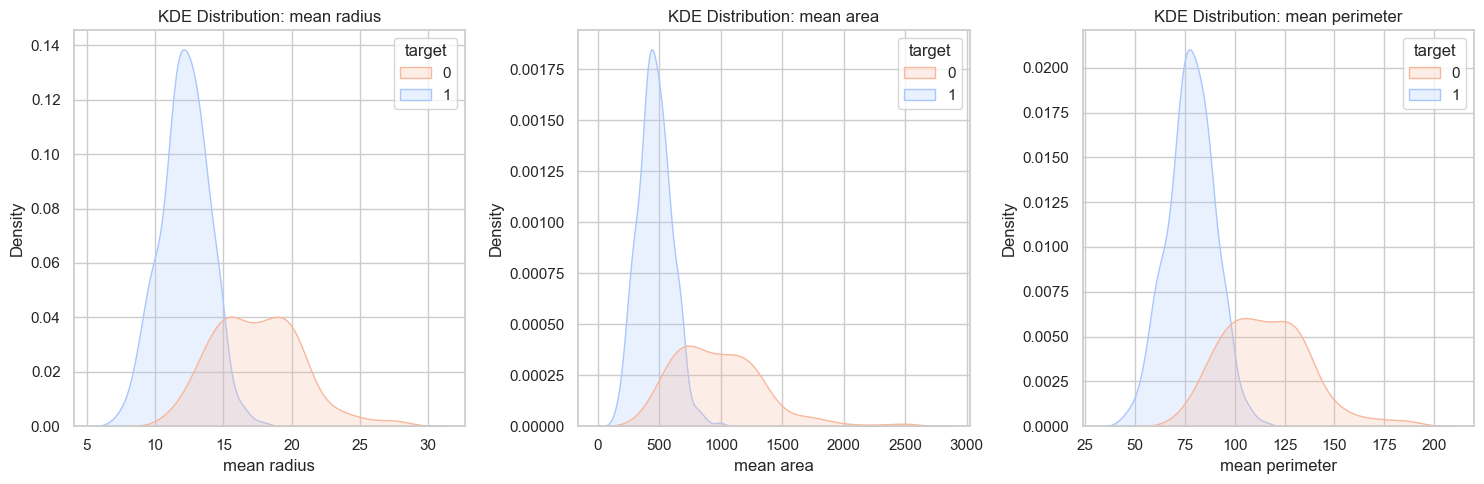

In [14]:
# Compare feature distributions between benign and malignant tumors
features_to_plot = ["mean radius", "mean area", "mean perimeter"] # List of features we want to plot

plt.figure(figsize=(15,5)) # Create a figure with 3 subplots side by side


# Loop through each feature and its index

for i, feat in enumerate(features_to_plot):  
    plt.subplot(1, 3, i+1)                  # Add a subplot: 1 row, 3 columns, current position i+1
    sns.kdeplot(data=df,                    # Draw a smooth density curve (KDE) for the feature
                x=feat,
                hue="target",               # separate curves for benign (0) and malignant (1)
                fill=True,                  # shade the area under the curve
                palette="coolwarm_r"        # use blue/red colors for the two groups
                ) 
    plt.title(f"KDE Distribution: {feat}")

plt.tight_layout()                          # Adjust spacing so titles/labels don't overlap
plt.show()


### Interpretation of the KDE Plot

- I plotted the KDE distributions of three features: radius, area, and perimeter for both benign (1) and malignant (0) tumors.
- The malignant curves are shifted to the right, which means they usually have larger values. Bigger nuclei for malignant tumors make sense because cancer cells often look enlarged and irregular.
- There is still a lot of overlap in the middle parts, so size alone cannot cleanly separate the two groups.
- A small tumor can still be malignant, and a large one can be benign.
- Because no single feature is enough, using machine learning to combine multiple signals is the better option.

**Note**
- In the default coolwarm palette, the first class in the plot gets the blue color and the second one gets the red color.
- Since malignant is labeled as 0 and benign as 1 in this dataset, I used the coolwarm_r palette so malignant shows up in red and benign in blue, which makes the plot easier to read and interpret.

---

### 7.3 Visualizing Class Differences with Scatter Plots

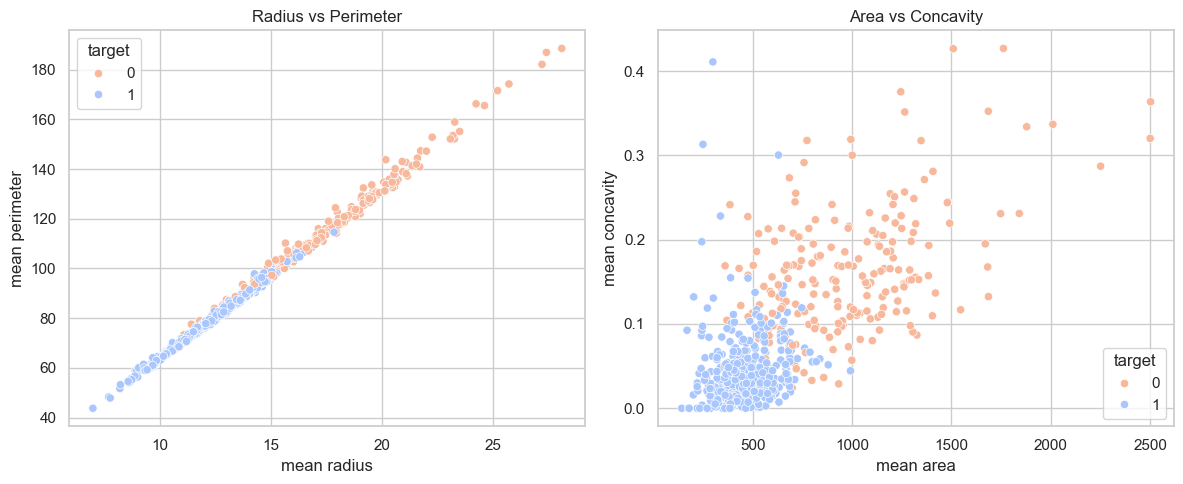

In [15]:
plt.figure(figsize=(12,5))


# Plot 1: Radius vs Perimeter 
plt.subplot(1,2,1)        # 1 row, 2 columns, 1st position
sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean perimeter",
    hue="target",
    palette="coolwarm_r") # 0=malignant (red), 1=benign (blue)
plt.title("Radius vs Perimeter")


# Plot 2: Area vs Concavity (size vs shape feature)
plt.subplot(1,2,2)        # 2nd position
sns.scatterplot(
    data=df,
    x="mean area",
    y="mean concavity",
    hue="target",
    palette="coolwarm_r") 
plt.title("Area vs Concavity")


plt.tight_layout()
plt.show()


### Interpretation of the Scatter Plot

In the first plot :
- Mean radius and mean perimeter have a very strong positive relationship. This is expected because both features measure tumor size.

- Malignant samples are mostly located in the upper right, which means they tend to have larger radius and perimeter values.

- Benign samples are more concentrated in the lower left, although there is still some overlap between the two groups.
  

In the second plot :

- Mean area and mean concavity also show a visible pattern.

- Malignant tumors generally have larger area and higher concavity, which suggests they are not only bigger but also more irregular in shape.

- Benign tumors stay more clustered in the lower area and lower concavity region, while malignant ones are more spread out.
  
  Overall, both plots show partial separation between the two classes, but not a perfect one. This means simple visual rules are helpful, but a machine learning model is still needed for better classification.

---

### 7.4 Box Plots for Outliers

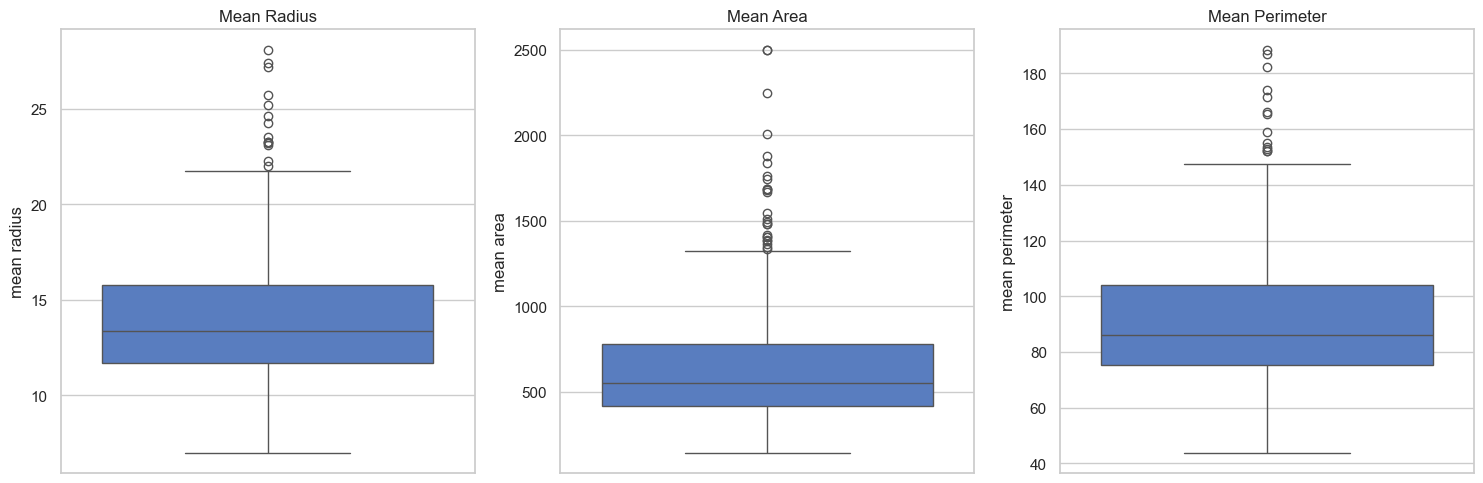

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15,5)) # a figure with 3 side by side plots


# Boxplot for mean radius
sns.boxplot(y=X["mean radius"], ax=axes[0])
axes[0].set_title("Mean Radius")

# Boxplot for mean area
sns.boxplot(y=X["mean area"], ax=axes[1])
axes[1].set_title("Mean Area")

# Boxplot for mean perimeter
sns.boxplot(y=X["mean perimeter"], ax=axes[2])
axes[2].set_title("Mean Perimeter")

plt.tight_layout()
plt.show()

### Interpretation of the Box Plots

These three boxplots show how each feature is spread out in the dataset.

- Mean radius has a tighter distribution, meaning most tumors fall within a similar range for this feature.
- Mean area is more spread out, so some tumors are much larger than others.
- Mean perimeter also shows a wider range, similar to the area feature.

Overall, these plots suggest that tumor size features vary quite a lot between samples, and this variation can be helpful later when trying to distinguish between benign and malignant cases.
 

---


## 8. Split the data
### Split the data into training and test sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                   # features
    y,                   # labels
    test_size=0.2,       # test_size=0.2 means 20% of the data is used for testing
    stratify=y,          # stratify=y keeps the same class ratio in both train and test
    random_state=42      # random_state=42 makes the split reproducible
)

- 80%  of the data is used for training the model, and the remaining 20% is kept aside to test how well the model performs on new data.
- We need separate training and test sets so we can evaluate the model fairly.
- Using stratify makes sure both sets have the same proportion of malignant and benign samples.
- Setting a random_state helps us get the same split every time, so results stay consistent.

---

## 9. Scaling

In [18]:
# Initialize the scaler for feature scaling
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

- Scaling is important in this project because some models do not work well when features have very different ranges.
- SVM and KNN are very sensitive to feature scales.
- If one feature has much bigger numbers than the others, it can dominate the result.
- Logistic Regression also works more smoothly when features are on a similar scale.

  In short, scaling makes sure that no single feature becomes more important just because it has larger values.
---


## 10. Principal Component Analysis (PCA) for Data Visualization

Explained variance ratio (PC1, PC2): [0.44413492 0.18944618]
Total explained variance by 2 PCs: 0.633581100677249


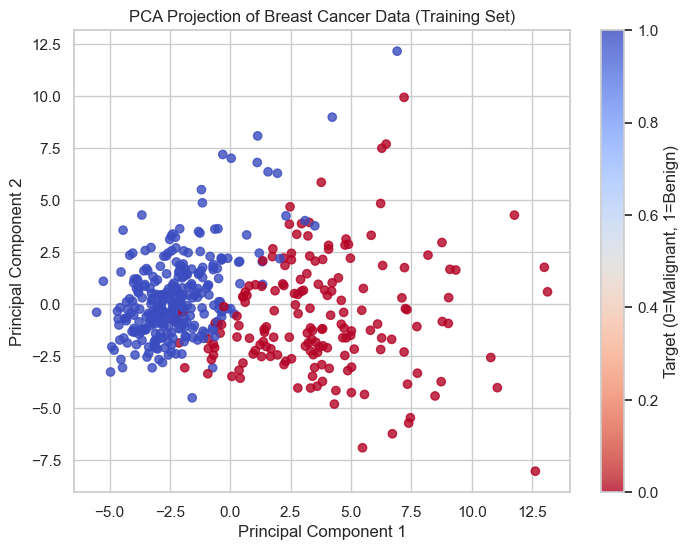

In [19]:
# Apply PCA to reduce the data to 2 components for visualization
pca = PCA(n_components=2, random_state=42)

# Fit PCA on the scaled training data and transform it
X_train_pca = pca.fit_transform(X_train_scaled)

# Apply the same PCA transformation to the test data
X_test_pca = pca.transform(X_test_scaled)

# Check how much variance is explained by the 2 principal components
explained_var = pca.explained_variance_ratio_

print("Explained variance ratio (PC1, PC2):", explained_var)
print("Total explained variance by 2 PCs:", explained_var.sum())

# Plot the training data in the new 2D PCA space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap="coolwarm_r",
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Breast Cancer Data (Training Set)")

# Add a colorbar to show the class labels
plt.colorbar(scatter, label="Target (0=Malignant, 1=Benign)")
plt.show()



- We use PCA to reduce the number of features in the dataset while keeping most of the important information.

- The original dataset has many features, which makes it difficult to visualize directly.

- By using PCA, we transform the data into two new components.

- This allows us to plot the data in two dimensions and visually explore whether benign and malignant tumors show different patterns.

- PCA is used here mainly for visualization and exploration, not for building the final model.

### Interpretation of the PCA Plot

- The scatter plot shows the samples after reducing the data to two principal components.
- Each point represents one tumor sample, and the color indicates whether it is benign or malignant.
- From the plot, we can see that the two classes form partially different regions.
- There is some separation between benign and malignant samples, although there is still some overlap.
- This suggests that the original features contain useful information for distinguishing between the two classes.
- Since the data been reduced to only two components, some information is lost, which explains why the separation is not perfect.

Overall, the PCA plot gives a simple visual indication that the dataset contains patterns that may help machine learning models classify tumors as benign or malignant.

**Explained variance ratio (PC1, PC2): [0.44413492 0.18944618]**

**Total explained variance by 2 PCs: 0.633581100677249**

- The first principal component explains about 44% of the total variance, and the second one explains about 19%.
- Together, the two components keep around 63% of the information from the original dataset.
- This means that even though we reduced the data to only two dimensions, we are still keeping a good amount of the overall structure of the dataset.
- However, since 63% is not close to 100 percent, it is normal to see some overlap between benign and malignant samples in the PCA plot.

---

## 11. Classification Models: Training and Prediction 

### 11.1 Training the Models

In [20]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# SVM
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Random Forest (no scaling needed)
rf_model = RandomForestClassifier(
    n_estimators=200,             # number of trees in the forest | use 200 trees for more stable predictions
    random_state=42
)
rf_model.fit(X_train, y_train);


- We train several models to compare different ways of separating the classes and see which one works best on this dataset.
- Each model looks at the data from a different angle, so this gives a fair and practical comparison.


- **Logistic Regression**: A simple linear model and a strong baseline

- **SVM**: Focuses on finding a clear boundary between classes. Works well when classes are not easily separable.

- **KNN**: Makes predictions based on the closest samples.

- **Random Forest**: Combines many decision trees to make predictions and it does not require feature scaling.

### 11.2 Making Predictions


In [21]:
# Generate predictions for the test set using the trained models
log_pred = log_model.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

- In this step, we use the trained models to make predictions on the test data.

- The test set contains data the models have never seen before, so this helps us evaluate how well they generalize to new samples.

- Logistic Regression, SVM, and KNN use the scaled test data because they are sensitive to feature magnitude.

- Random Forest uses the original test data since tree-based models do not require scaling.

- The output of each model is a predicted class label for every sample in the test set. These predictions will later be compared with the true labels to measure model performance.
---


## 12. Evaluation


### 12.1 Classification reports
This code generates a classification report for each machine learning model and displays the results as tables.

In [22]:
# output_dict=True returns the metrics as a dictionary instead of plain text.
reports = {
    "Logistic Regression": classification_report(y_test, log_pred, output_dict=True),
    "SVM": classification_report(y_test, svm_pred, output_dict=True),
    "KNN": classification_report(y_test, knn_pred, output_dict=True),
    "Random Forest": classification_report(y_test, rf_pred, output_dict=True)
}

# Convert each report to a pandas DataFrame and display it as a table.
for name, report in reports.items():
    df = pd.DataFrame(report).transpose()
    print(f"\n{name}")
    display(df.round(3))
    
    


Logistic Regression


,precision,recall,f1-score,support
0,0.976,0.976,0.976,42.000
1,0.986,0.986,0.986,72.000
accuracy,0.982,0.982,0.982,0.982
macro avg,0.981,0.981,0.981,114.000
weighted avg,0.982,0.982,0.982,114.000



SVM


,precision,recall,f1-score,support
0,0.976,0.976,0.976,42.000
1,0.986,0.986,0.986,72.000
accuracy,0.982,0.982,0.982,0.982
macro avg,0.981,0.981,0.981,114.000
weighted avg,0.982,0.982,0.982,114.000



KNN


,precision,recall,f1-score,support
0,0.951,0.929,0.940,42.000
1,0.959,0.972,0.966,72.000
accuracy,0.956,0.956,0.956,0.956
macro avg,0.955,0.950,0.953,114.000
weighted avg,0.956,0.956,0.956,114.000



Random Forest


,precision,recall,f1-score,support
0,0.951,0.929,0.940,42.000
1,0.959,0.972,0.966,72.000
accuracy,0.956,0.956,0.956,0.956
macro avg,0.955,0.950,0.953,114.000
weighted avg,0.956,0.956,0.956,114.000


- Each report includes important evaluation metrics such as precision, recall, F1-score, and support for each class, as well as overall performance measures.
- By using output_dict=True, the classification report is returned as a dictionary instead of plain text. This allows the results to be easily converted into a pandas DataFrame and displayed in a cleaner tabular format.
- This makes it easier to compare how different models perform on the test set.
---

1. Precision
- Precision measures how many of the samples predicted as positive are actually positive.
Formula = True Positives / (True Positives + False Positives)
- A high precision means the model makes fewer false positive predictions.
- Precision is important when we want to avoid incorrectly labeling healthy people as diseased.

---

2. Recall
- Recall measures how many of the actual positive samples are correctly identified by the model.
- Formula = True Positives / (True Positives + False Negatives)
- A high recall means the model misses fewer real positive cases.
- Recall is often very important because missing a true patient can be more dangerous than making a false alarm.

---

3. F1-score
- F1-score is the harmonic mean of precision and recall.
- It gives a balanced measure of model performance when both false positives and false negatives matter.
- It is especially helpful when the dataset is imbalanced.

---

4. Support
- Support is the number of actual samples belonging to each class in the test set.
- It shows how many examples were used to calculate the metrics for each class.

---

5. Accuracy
- Accuracy measures the overall proportion of correct predictions.
- Formula = Correct Predictions / Total Predictions
- It gives a general summary of performance, but it may be misleading if the classes are imbalanced.

---

### 12.2 Comparison Table
- A summary table to compare the overall performance of all models :

In [23]:
summary_rows = []

for name, report in reports.items():
    summary_rows.append({
        "Model": name,
        "Accuracy": report["accuracy"],                               # Overall prediction accuracy
        "Precision (weighted)": report["weighted avg"]["precision"],  # Weighted precision across classes
        "Recall (weighted)": report["weighted avg"]["recall"],        # Weighted recall across classes
        "F1-score (weighted)": report["weighted avg"]["f1-score"]     # Balanced performance metric
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(3))

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.982,0.982,0.982,0.982
1,SVM,0.982,0.982,0.982,0.982
2,KNN,0.956,0.956,0.956,0.956
3,Random Forest,0.956,0.956,0.956,0.956


### Model comparison interpretation

- The table summarizes the overall performance of the four classification models in predicting breast cancer diagnosis based on accuracy, weighted precision, weighted recall, and weighted F1-score.

- Logistic Regression and SVM achieved the highest performance across all metrics, each obtaining a score of 0.982.
- This indicates that both models were highly effective in distinguishing between malignant and benign tumors.
- Their high weighted F1-scores also suggest a strong balance between precision and recall across the dataset.

- KNN and Random Forest achieved slightly lower scores of 0.956 across all evaluation metrics.
- Although these models still demonstrate strong classification ability, their performance indicates slightly weaker generalization compared to Logistic Regression and SVM.

Overall, Logistic Regression and SVM appear to be the most reliable models for this breast cancer classification task, showing superior accuracy and balanced predictive performance.

---

### 12.3 Confusion matrix
We will plot the confusion matrix for each model

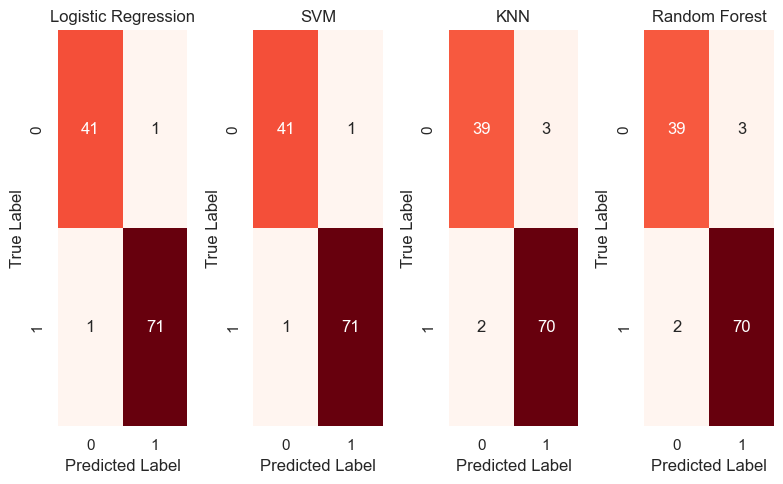

In [24]:
models_preds = [
    ("Logistic Regression", log_pred),   #Create a list of model names and their prediction
    ("SVM", svm_pred),
    ("KNN", knn_pred),
    ("Random Forest", rf_pred)
]

# Loop through each model and plot its confusion matrix
for i, (name, pred) in enumerate(models_preds, start=1):
    plt.subplot(1, 4, i)  # Create 4 plots in one row
    
    cm = confusion_matrix(y_test, pred)  # Compute confusion matrix
    
    # Plot confusion matrix as a heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Reds",
        cbar=False
        )
    
    plt.title(f"{name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()


### Interpretation of the Confusion Matrices

- The confusion matrices show how each model classified benign and malignant tumors.

- Logistic Regression and SVM show almost perfect classification performance.

- They have very few false positives and false negatives, indicating strong reliability in detecting both malignant and benign tumors.

- KNN and Random Forest also perform well, but they show slightly more misclassifications compared to Logistic Regression and SVM.

### False Negatives 
- In medical diagnosis, false negatives are more dangerous than false positives.

- A false negative means a malignant tumor is classified as benign.

- Logistic Regression and SVM have the lowest number of false negatives, making them more suitable for medical screening tasks.

### False positives
- False positives mean predicting malignant when it is actually benign.

- While less critical than false negatives, too many false positives can cause unnecessary stress and additional medical tests.

- All models show relatively low false positives, but again Logistic Regression and SVM appear slightly more balanced.

- Although all four models perform strongly, Logistic Regression and SVM demonstrate the best balance between sensitivity and overall accuracy.

- This makes them the most reliable choices for breast cancer classification in this dataset.

---

### 12.4 ROC Analysis for Model Comparison


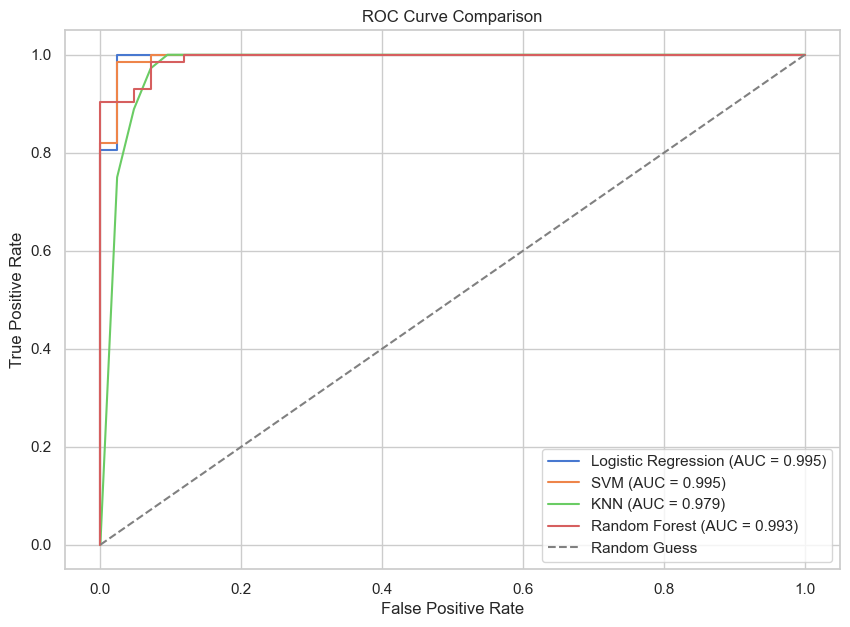

In [25]:
# ROC Curves for All Models
# Predicted probabilities for the positive class (malignant = 1)
# For models trained on scaled features, we use X_test_scaled

log_prob = log_model.predict_proba(X_test_scaled)[:, 1]   # Probability of class 1 for Logistic Regression
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]   # Probability of class 1 for SVM
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]   # Probability of class 1 for KNN

# Random Forest is trained on the original (unscaled) features
rf_prob = rf_model.predict_proba(X_test)[:, 1]            # Probability of class 1 for Random Forest


plt.figure(figsize=(10, 7))

# Loop through each model and plot its ROC curve
for name, probs in [
    ("Logistic Regression", log_prob),
    ("SVM", svm_prob),
    ("KNN", knn_prob),
    ("Random Forest", rf_prob)
]:
    # Compute False Positive Rate (fpr) and True Positive Rate (tpr) at different classification thresholds
    fpr, tpr, _ = roc_curve(y_test, probs)

    # Compute the Area Under the Curve (AUC) for the current model
    model_auc = auc(fpr, tpr)

    # Plot the ROC curve with the model name and its AUC in the legend
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {model_auc:.3f})"
    )

# Plot the diagonal reference line (random classifier)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

# Show the legend (model names + AUC scores)
plt.legend()

plt.show()


### How to read the ROC curve 


- The x-axis (False Positive Rate) shows how often the model raises a false alarm.
- The y-axis (True Positive Rate) shows how often the model correctly detects the positive class (malignant tumors).
- A good model has a curve that goes up quickly and stays close to the top-left corner.
- The closer the curve is to the top-left and the higher the AUC, the better the model is at distinguishing malignant from benign cases.

### ROC Curve Analysis

- The ROC curve shows how well each model separates the two classes by comparing the True Positive Rate and False Positive Rate at different thresholds.
- Logistic Regression and SVM achieved the highest AUC (0.995), showing excellent classification performance.
- Random Forest also performed very well with an AUC of 0.993.
- KNN had a slightly lower AUC (0.979), indicating weaker performance compared to the other models.
Overall, Logistic Regression and SVM performed best based on the ROC‑AUC metric.

---

## 13. Best Model Selection

- After comparing all models using classification metrics, confusion matrices, and ROC curves, Logistic Regression and SVM achieved the best overall performance on the dataset.

- Both models produced the highest accuracy and F1-scores while also achieving excellent ROC-AUC values, indicating strong classification capability.

- Random Forest also performed well and provided useful feature importance analysis, although its overall performance was slightly lower.
- KNN showed comparatively lower performance than the other models.

Overall, Logistic Regression and SVM were selected as the most reliable models for this classification task.

---

## 14. Model Interpretation

### 14.1 Feature Importance (Random Forest)

Although Random Forest is not the top-performing model, it provides useful feature importance scores that help interpret the contribution of different features.

In [26]:
# Extract feature importance scores from the trained Random Forest model
importances = rf_model.feature_importances_

# Create a DataFrame linking features with their importance scores
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort features by importance
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)


feat_imp = feat_imp.head(10)    # Top Features


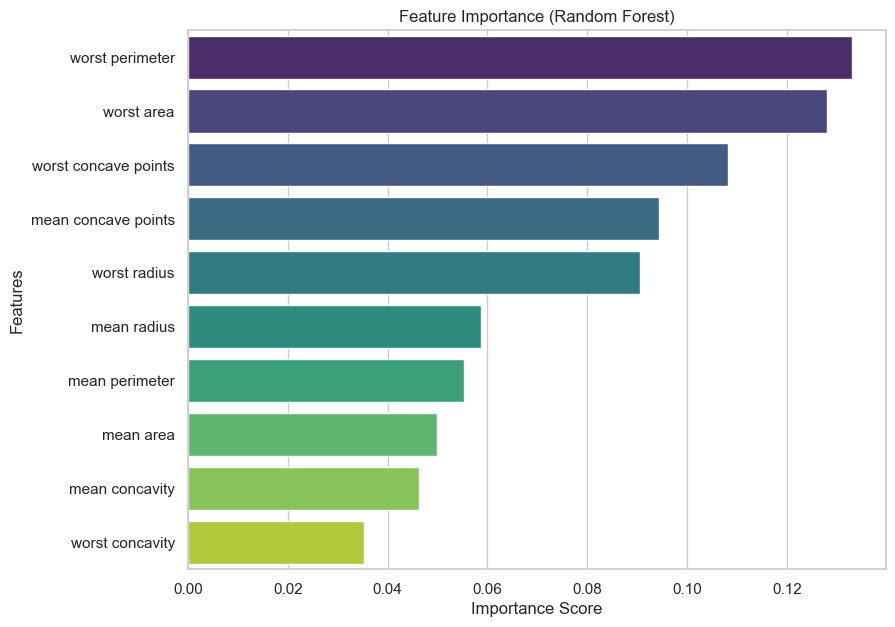

In [27]:
plt.figure(figsize=(9, 7))

sns.barplot(
    data=feat_imp,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()


### Feature Importance Interpretation
- The chart shows which features the Random Forest model relied on most when making predictions.
- The most important features include worst perimeter, worst area, and mean concave points.
- These features describe the size and shape of the tumor, suggesting that tumor geometry plays a key role in distinguishing between malignant and benign cases.
- Feature importance is shown for the Random Forest model because tree‑based models naturally compute importance scores during training.

---

### 14.2 SHAP Analysis

SHAP explainer for Logistic Regression

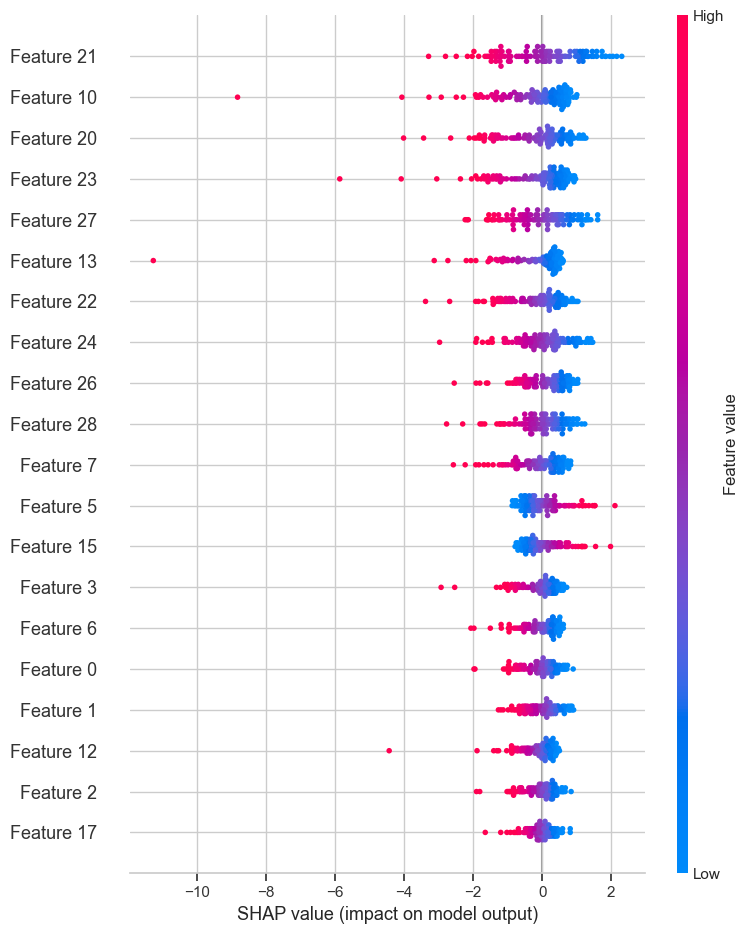

In [28]:
# Create SHAP explainer for Logistic Regression
explainer = shap.Explainer(log_model, X_train_scaled)

# Calculate SHAP values
shap_values = explainer(X_test_scaled)

# Summary plot showing feature impact
shap.summary_plot(shap_values, X_test_scaled)


### SHAP Interpretation (Logistic Regression)
- Both Logistic Regression and SVM achieved very similar performance in the evaluation phase. In this section, Logistic Regression is selected for SHAP interpretation because it is a simpler and more interpretable model.
- SHAP analysis helps explain how individual features influence the model’s predictions.
- The summary plot below shows the contribution of each feature to the classification outcome.
- The dataset contains 30 numerical features describing characteristics of cell nuclei. Some features appear as indexed variables, but they represent measurements related to tumor size, texture, and shape.
- The SHAP results show that several features have a strong impact on the model’s predictions, indicating that geometric and structural properties of the tumor play a key role in distinguishing malignant from benign tumors.

---

Bar plot of global feature importance

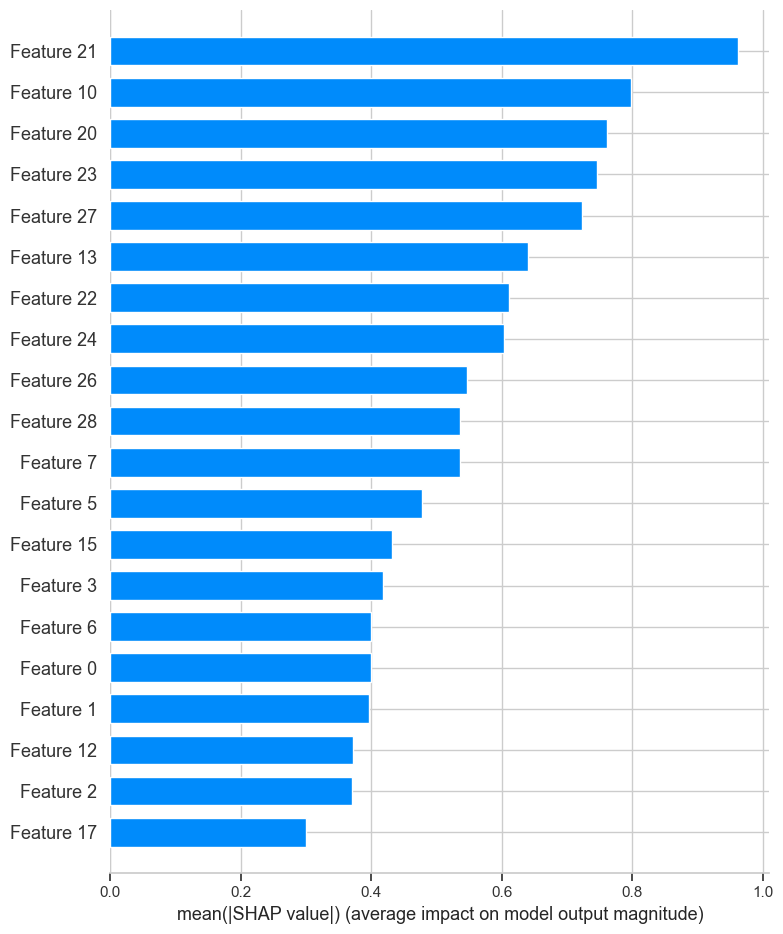

In [29]:
# Bar plot of global feature importance
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")


## 15. Summary of Results
- In this project, multiple machine learning models were trained to classify breast tumors as malignant or benign using the Wisconsin Breast Cancer dataset.
- The models were evaluated using several performance metrics including accuracy, precision, recall, F1-score, and ROC-AUC.
- The results showed that Logistic Regression and SVM achieved the best overall performance.
- Both models demonstrated strong predictive ability and balanced evaluation metrics, indicating that they can effectively distinguish between malignant and benign tumors.
---

## 16. Medical Interpretation
- The interpretation results indicate that features related to tumor size, perimeter, and concave points have the strongest influence on model predictions. These characteristics describe the geometric structure of the tumor cells.
- This observation aligns with medical knowledge, as malignant tumors often show irregular shapes, larger sizes, and more complex boundaries compared to benign tumors.

---

## 17. Limitations
- Although the models achieved strong performance, this study has several limitations.
- The dataset used in this project is relatively small and originates from a single source. In real-world medical settings, datasets are often larger and more diverse.
- Additionally, the models were trained on structured numerical features rather than raw medical images, which limits the scope of the analysis.

---

## 18. Future Work
- Future work could explore the use of larger and more diverse medical datasets to improve model generalization.
- Deep learning approaches applied to medical imaging data may also provide additional insights.
- Furthermore, advanced model interpretation techniques could be used to better understand the decision-making process of complex machine learning models in medical diagnosis tasks.
---

### References
Scikit-learn Developers. Breast Cancer Wisconsin Dataset.
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

Scikit-learn Documentation. Machine Learning in Python.
https://scikit-learn.org

SHAP Documentation. SHAP (SHapley Additive Explanations).
https://shap.readthedocs.io

Matplotlib Documentation. Visualization with Python.
https://matplotlib.org

Seaborn Documentation. Statistical Data Visualization in Python.
https://seaborn.pydata.org


---

By : Sahel Sepehri
- github.com/sahelsepehri
- sahelsepehri99@gmail.com